# КИМ 5.1. LSTM, GRU и 1D-CNN (PyTorch) — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-05-sequences.ipynb`](./kim-05-sequences.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В решении нет зависимости от Keras: предобработка текста, модели,
циклы обучения и датасет временных окон реализованы явно. По умолчанию часть с
текстом загружает закреплённый опубликованный сплит `train` Russian Reviews
Classification и берёт из него фиксированную стратифицированную подвыборку.
Локальные train/validation/test не являются официальными сплитами набора. Для
автономной проверки реализации доступен явно обозначенный синтетический режим.
Все напечатанные метрики получаются при текущем запуске.

Полный запуск рекомендуется выполнять с GPU; ручной цикл `LSTMCell` с recurrent
dropout на CPU может занять заметно больше времени. Для Jena Climate используется
репрезентативная хронологическая подвыборка целевых моментов, но физический смысл
каждого окна (5 суток истории и прогноз на 24 часа вперёд) сохраняется.

---
## Общая настройка

In [1]:
import hashlib
import random
import re
import subprocess
import sys
import tempfile
import time
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import nltk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymorphy3
import torch
from nltk.tokenize import word_tokenize
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Эти настройки делают CUDA-запуски воспроизводимее. На CPU они безвредны.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Устройство:", DEVICE)

PyTorch: 2.5.1+cu121
Устройство: cuda


---
## Часть А. Предобработка русских текстов

### 1. Regex-нормализация и автоматические тесты

До токенизации заменяем URL, e-mail и числа устойчивыми маркерами. Пять `assert`
проверяют обычные случаи, регистр, несколько пробелов и отсутствие ложных
срабатываний.

In [2]:
URL_RE = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
EMAIL_RE = re.compile(r'\b[\w.+-]+@[\w.-]+\.[A-Za-zА-Яа-я]{2,}\b')
NUMBER_RE = re.compile(r'(?<!\w)[+-]?(?:\d+[.,]?\d*|[.,]\d+)(?!\w)')
SPACE_RE = re.compile(r'\s+')


def normalize_markup(text):
    normalized = str(text)
    normalized = URL_RE.sub(' <URL> ', normalized)
    normalized = EMAIL_RE.sub(' <EMAIL> ', normalized)
    normalized = NUMBER_RE.sub(' <NUMBER> ', normalized)
    return SPACE_RE.sub(' ', normalized).strip()


assert normalize_markup('Сайт https://example.org/a') == 'Сайт <URL>'
assert normalize_markup('Пишите A.User+tag@mail.ru') == 'Пишите <EMAIL>'
assert normalize_markup('Комиссия 12,5 рублей') == 'Комиссия <NUMBER> рублей'
assert normalize_markup('  два\nпробела\tздесь ') == 'два пробела здесь'
assert normalize_markup('модель resnet50') == 'модель resnet50'
print('Regex-тесты: 5/5')

Regex-тесты: 5/5


### 2. Токенизация, стоп-слова и лемматизация

Сначала текст приводится к нижнему регистру и разбивается именно
`nltk.word_tokenize`. Режим `preserve_line=True` не требует внешней модели
`punkt`. Для модельного конвейера используется фиксированный встроенный список
стоп-слов: установленный или отсутствующий корпус NLTK не меняет входы моделей и
метрики. Корпус NLTK можно отдельно исследовать в учебных целях. Пунктуацию и
числа отбрасываем через `isalpha`, затем выполняем лемматизацию с помощью
`pymorphy3.MorphAnalyzer`.

In [3]:
morph = pymorphy3.MorphAnalyzer()

MODEL_STOPWORDS = frozenset({
    "а", "без", "более", "бы", "был", "была", "были", "было", "быть",
    "в", "вам", "вас", "весь", "во", "вот", "все", "всего", "вы", "где",
    "да", "даже", "для", "до", "его", "ее", "если", "есть", "еще", "же",
    "за", "здесь", "и", "из", "или", "им", "их", "к", "как", "когда",
    "кто", "ли", "либо", "мне", "может", "мы", "на", "над", "надо", "наш",
    "не", "него", "нее", "нет", "ни", "них", "но", "ну", "о", "об", "однако",
    "он", "она", "они", "оно", "от", "очень", "по", "под", "при", "про",
    "раз", "с", "сам", "себе", "себя", "так", "также", "такой", "там", "те",
    "тем", "то", "того", "тоже", "только", "том", "ты", "у", "уже", "хотя",
    "чего", "чем", "что", "чтобы", "эта", "эти", "это", "я",
})
print("Фиксированных модельных стоп-слов:", len(MODEL_STOPWORDS))


def preprocess(text):
    tokens = word_tokenize(
        normalize_markup(text).lower(), language="russian", preserve_line=True,
    )
    lemmas = []
    for token in tokens:
        if not token.isalpha() or token in MODEL_STOPWORDS:
            continue
        lemma = morph.parse(token)[0].normal_form
        if lemma not in MODEL_STOPWORDS:
            lemmas.append(lemma)
    return lemmas


example = "Банк быстро решил мою проблему, а сотрудники были очень вежливы!"
print("Исходный текст:", example)
print("После preprocess:", preprocess(example))

Фиксированных модельных стоп-слов: 98
Исходный текст: Банк быстро решил мою проблему, а сотрудники были очень вежливы!
После preprocess: ['банк', 'быстро', 'решить', 'мой', 'проблема', 'сотрудник', 'вежливый']


### 3. Синтаксический разбор пяти предложений

Natasha возвращает для каждого токена идентификатор вершины, `head_id` и тип
синтаксической связи. Если пакет отсутствует, эталон устанавливает его в текущее
окружение.

In [4]:
try:
    from natasha import Doc, NewsEmbedding, NewsMorphTagger, NewsSyntaxParser, Segmenter
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'natasha'])
    from natasha import Doc, NewsEmbedding, NewsMorphTagger, NewsSyntaxParser, Segmenter

segmenter = Segmenter()
embedding = NewsEmbedding()
morph_tagger = NewsMorphTagger(embedding)
syntax_parser = NewsSyntaxParser(embedding)
syntax_sentences = [
    'Банк быстро одобрил заявку.',
    'Сотрудник подробно объяснил условия кредита.',
    'Приложение часто зависает после обновления.',
    'Поддержка не ответила на обращение клиента.',
    'Низкая комиссия сделала перевод выгодным.',
]
syntax_rows = []
for sentence_index, sentence in enumerate(syntax_sentences, start=1):
    document = Doc(sentence)
    document.segment(segmenter)
    document.tag_morph(morph_tagger)
    document.parse_syntax(syntax_parser)
    for token in document.tokens:
        syntax_rows.append({
            'sentence': sentence_index,
            'token_id': token.id,
            'token': token.text,
            'head_id': token.head_id,
            'dependency': token.rel,
        })

syntax_table = pd.DataFrame(syntax_rows)
print(syntax_table.to_string(index=False))
assert syntax_table['sentence'].nunique() == 5
assert syntax_table['dependency'].notna().all()

 sentence token_id      token head_id dependency
        1      1_1       Банк     1_3      nsubj
        1      1_2     быстро     1_3     advmod
        1      1_3    одобрил     1_0       root
        1      1_4     заявку     1_3        obj
        1      1_5          .     1_3      punct
        2      1_1  Сотрудник     1_3      nsubj
        2      1_2   подробно     1_3     advmod
        2      1_3   объяснил     1_0       root
        2      1_4    условия     1_3        obj
        2      1_5    кредита     1_4       nmod
        2      1_6          .     1_3      punct
        3      1_1 Приложение     1_3      nsubj
        3      1_2      часто     1_3     advmod
        3      1_3   зависает     1_0       root
        3      1_4      после     1_5       case
        3      1_5 обновления     1_3        obl
        3      1_6          .     1_3      punct
        4      1_1  Поддержка     1_3      nsubj
        4      1_2         не     1_3     advmod
        4      1_3  

В предложении «Банк быстро одобрил заявку» `одобрил` является
корнем, `банк` связан с ним как подлежащее, а `заявку` — как дополнение. Связь
наречия `быстро` описывает обстоятельство действия. Во втором предложении
`сотрудник` — подлежащее при сказуемом `объяснил`, а `условия` — его дополнение.
Точные метки зависят от версии модели, поэтому проверяется структура, а не
заранее заданный список идентификаторов.

### 4. Данные и построение словаря

Набор [`ai-forever/ru-reviews-classification`](https://huggingface.co/datasets/ai-forever/ru-reviews-classification)
имеет метку Apache-2.0 в метаданных, но карточка не описывает происхождение
текстов; копия данных не включается в репозиторий. Эталон кэширует `train.jsonl`
из закреплённого revision `0f67d914f396ce22917dc6463ec619799b3b08d2` и
проверяет SHA-256. Новый файл сначала скачивается во временный файл и только после
проверки атомарно заменяет кэш. Каталог данных определяется и при запуске из
каталога ноутбука, и из корня репозитория.

Из опубликованного сплита `train` исключаются нейтральные отзывы, затем при
`seed=42` берётся по 500 объектов negative/positive. Эта фиксированная
подвыборка локально делится на train/validation/test размером 640/160/200.
Локальный test не является официальным test-сплитом и его метрики нельзя так
называть. Чтобы проверить код без сети, можно переключить
`USE_RU_REVIEWS = False`; метрики синтетического режима нельзя интерпретировать
как качество на реальных данных.

In [5]:
USE_RU_REVIEWS = True
RU_REVIEWS_REVISION = "0f67d914f396ce22917dc6463ec619799b3b08d2"
RU_REVIEWS_URL = (
    "https://huggingface.co/datasets/ai-forever/"
    f"ru-reviews-classification/resolve/{RU_REVIEWS_REVISION}/train.jsonl"
)
RU_REVIEWS_SHA256 = "0b97698a0c6871437d17e07c973018af9b8c9230ec9048d85cb875cc2c2470ea"
TEXT_SAMPLES_PER_CLASS = 500


def locate_m5_data_dir():
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        if (base / "kim-05-sequences.ipynb").is_file():
            return base / "data"

        repo_attachments = base / "M5-sequences" / "attachments"
        if (repo_attachments / "kim-05-sequences.ipynb").is_file():
            return repo_attachments / "data"

        module_attachments = base / "attachments"
        if (module_attachments / "kim-05-sequences.ipynb").is_file():
            return module_attachments / "data"

    # Обычный notebook-контекст без доступного дерева репозитория.
    return cwd / "data"


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as source:
        for chunk in iter(lambda: source.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def ensure_cached_file(url, destination, expected_sha256):
    destination.parent.mkdir(parents=True, exist_ok=True)
    try:
        display_path = destination.relative_to(Path.cwd())
    except ValueError:
        display_path = Path(destination.name)
    if destination.exists():
        actual_sha256 = sha256_file(destination)
        if actual_sha256 == expected_sha256:
            print("Проверен кэш:", display_path)
            return destination
        print("SHA-256 кэша не совпал; скачиваем проверенную копию:", display_path)

    with tempfile.NamedTemporaryFile(
        dir=destination.parent,
        prefix=f"{destination.name}.",
        suffix=".tmp",
        delete=False,
    ) as temporary:
        temporary_path = Path(temporary.name)

    try:
        urllib.request.urlretrieve(url, temporary_path)
        actual_sha256 = sha256_file(temporary_path)
        if actual_sha256 != expected_sha256:
            raise RuntimeError(
                f"SHA-256 скачанного файла {actual_sha256}, ожидался {expected_sha256}"
            )
        temporary_path.replace(destination)
    finally:
        temporary_path.unlink(missing_ok=True)

    print("Скачан и проверен кэш:", display_path)
    return destination


DATA_DIR = locate_m5_data_dir()
RU_REVIEWS_PATH = DATA_DIR / "ru_reviews" / "train.jsonl"

if USE_RU_REVIEWS:
    ensure_cached_file(RU_REVIEWS_URL, RU_REVIEWS_PATH, RU_REVIEWS_SHA256)
    reviews_df = pd.read_json(RU_REVIEWS_PATH, lines=True)
    required_columns = {"text", "label_text"}
    if not required_columns.issubset(reviews_df.columns):
        raise ValueError("В наборе ожидаются столбцы text и label_text")
    reviews_df = reviews_df[reviews_df["label_text"].isin(["negative", "positive"])].copy()
    reviews_df["label"] = reviews_df["label_text"].map({"negative": 0, "positive": 1})
    class_counts = reviews_df["label"].value_counts()
    if (class_counts < TEXT_SAMPLES_PER_CLASS).any():
        raise ValueError(f"Недостаточно объектов для фиксированной подвыборки: {class_counts}")
    reviews_df = pd.concat(
        [
            group.sample(
                n=TEXT_SAMPLES_PER_CLASS,
                random_state=SEED,
            )
            for _, group in reviews_df.groupby("label", sort=True)
        ],
        ignore_index=True,
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)
    texts = reviews_df["text"].fillna("").astype(str).tolist()
    labels = reviews_df["label"].astype("int64").to_numpy()
    dataset_kind = (
        "Russian Reviews Classification: фиксированная подвыборка из train "
        "(500 negative + 500 positive); локальные split 640/160/200"
    )
else:
    positive_phrases = [
        "банк быстро одобрил заявку и вежливо ответил",
        "сотрудник помог решить вопрос без очереди",
        "удобное приложение работает быстро и надёжно",
        "перевод пришёл мгновенно комиссия оказалась низкой",
        "поддержка подробно объяснила условия и помогла",
        "карта доставлена вовремя обслуживание отличное",
        "приятный офис и внимательный доброжелательный персонал",
        "вклад открыли быстро условия оказались выгодными",
        "оператор компетентно исправил ошибку в тот же день",
        "доволен банком все операции проходят без проблем",
        "кредит оформили честно и понятно без скрытых платежей",
        "спасибо поддержке за быстрый и полезный ответ",
    ]
    negative_phrases = [
        "банк долго рассматривает заявку и не отвечает",
        "сотрудник отказался помочь пришлось стоять в очереди",
        "неудобное приложение постоянно зависает и ломается",
        "перевод задержали и списали высокую комиссию",
        "поддержка не объяснила условия и закрыла обращение",
        "карту доставили поздно обслуживание ужасное",
        "грязный офис и грубый невнимательный персонал",
        "вклад закрывали долго условия оказались невыгодными",
        "оператор допустил ошибку и неделю её не исправлял",
        "разочарован банком операции постоянно отклоняются",
        "в кредите обнаружились непонятные скрытые платежи",
        "поддержка прислала бесполезный ответ после долгого ожидания",
    ]
    contexts = [
        "Отзыв клиента: {}.",
        "Недавно обратился в отделение. {}.",
        "Мой опыт работы с банком: {}.",
        "После обращения могу сказать следующее: {}.",
    ]
    texts = [template.format(phrase) for phrase in positive_phrases for template in contexts]
    labels = np.ones(len(texts), dtype=np.int64)
    negative_texts = [
        template.format(phrase) for phrase in negative_phrases for template in contexts
    ]
    texts.extend(negative_texts)
    labels = np.concatenate([labels, np.zeros(len(negative_texts), dtype=np.int64)])
    dataset_kind = "ДЕМО: синтетические русские отзывы"

print(dataset_kind)
print("Число текстов:", len(texts), "баланс классов:", np.bincount(labels))

Проверен кэш: data/ru_reviews/train.jsonl


Russian Reviews Classification: фиксированная подвыборка из train (500 negative + 500 positive); локальные split 640/160/200
Число текстов: 1000 баланс классов: [500 500]


In [6]:
MAX_WORDS = 10_000
MAXLEN = 200


def stratified_split_indices(y, test_fraction=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    train_indices, test_indices = [], []
    for label in np.unique(y):
        indices = np.flatnonzero(y == label)
        rng.shuffle(indices)
        test_size = max(1, int(round(len(indices) * test_fraction)))
        test_indices.extend(indices[:test_size])
        train_indices.extend(indices[test_size:])
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    return np.asarray(train_indices), np.asarray(test_indices)


def build_vocab(tokenized_texts, max_words=MAX_WORDS):
    frequencies = Counter(token for tokens in tokenized_texts for token in tokens)
    word_to_index = {"<PAD>": 0, "<OOV>": 1}
    for word, _ in frequencies.most_common(max_words - 2):
        word_to_index[word] = len(word_to_index)
    return word_to_index


def text_to_sequence(tokens, word_to_index, maxlen=MAXLEN):
    sequence = [word_to_index.get(token, 1) for token in tokens]
    # Предпаддинг: последнее состояние LSTM соответствует последнему слову, а не PAD.
    sequence = [0] * max(0, maxlen - len(sequence)) + sequence
    return sequence[-maxlen:]


train_pool_idx, test_idx = stratified_split_indices(labels)
relative_train_idx, relative_val_idx = stratified_split_indices(
    labels[train_pool_idx], test_fraction=0.2, seed=SEED + 1)
train_idx = train_pool_idx[relative_train_idx]
val_idx = train_pool_idx[relative_val_idx]
train_tokens = [preprocess(texts[i]) for i in train_idx]
val_tokens = [preprocess(texts[i]) for i in val_idx]
test_tokens = [preprocess(texts[i]) for i in test_idx]

# Словарь строится только по train, поэтому test не передаёт информацию в обучение.
word_to_index = build_vocab(train_tokens)
X_train = torch.tensor(
    [text_to_sequence(tokens, word_to_index) for tokens in train_tokens],
    dtype=torch.long,
)
X_test = torch.tensor(
    [text_to_sequence(tokens, word_to_index) for tokens in test_tokens],
    dtype=torch.long,
)
X_val = torch.tensor(
    [text_to_sequence(tokens, word_to_index) for tokens in val_tokens],
    dtype=torch.long,
)
y_train = torch.tensor(labels[train_idx], dtype=torch.float32)
y_val = torch.tensor(labels[val_idx], dtype=torch.float32)
y_test = torch.tensor(labels[test_idx], dtype=torch.float32)

assert word_to_index["<PAD>"] == 0 and word_to_index["<OOV>"] == 1
assert X_train.shape[1] == MAXLEN and int(X_train.max()) < MAX_WORDS
if USE_RU_REVIEWS:
    assert (len(X_train), len(X_val), len(X_test)) == (640, 160, 200)
print("Размер словаря:", len(word_to_index), "из максимальных", MAX_WORDS)
print("Train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print("Проверка PAD/OOV:", text_to_sequence(["совсемновоеслово"], word_to_index, 4))

Размер словаря: 1913 из максимальных 10000
Train/val/test: torch.Size([640, 200]) torch.Size([160, 200]) torch.Size([200, 200])
Проверка PAD/OOV: [0, 0, 0, 1]


---
## Часть Б. Классификация текста: LSTM, GRU и 1D-CNN

Обе модели возвращают **логиты**, поэтому используется численно
устойчивая `BCEWithLogitsLoss` (сигмоида уже включена в loss). `padding_idx=0`
фиксирует нулевой эмбеддинг для паддинга. В CNN `Conv1d` ожидает каналы перед
длиной последовательности, поэтому после `Embedding` оси переставляются.

In [7]:
text_train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
text_val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
text_test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size=MAX_WORDS, embedding_dim=64, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, token_ids):
        embedded = self.embedding(token_ids)             # (batch, length, 64)
        _, (hidden, _) = self.lstm(embedded)
        return self.output(hidden[-1]).squeeze(1)         # (batch,)


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size=MAX_WORDS, embedding_dim=64, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, token_ids):
        embedded = self.embedding(token_ids)
        _, hidden = self.gru(embedded)
        return self.output(hidden[-1]).squeeze(1)


class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size=MAX_WORDS, embedding_dim=64, channels=250):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, channels, kernel_size=5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(channels, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, token_ids):
        embedded = self.embedding(token_ids).transpose(1, 2)  # (batch, 64, length)
        features = torch.relu(self.conv(embedded))
        pooled = self.pool(features).squeeze(2)
        return self.classifier(pooled).squeeze(1)              # (batch,)


lstm_classifier = LSTMClassifier(hidden_size=64).to(DEVICE)
gru_classifier = GRUClassifier(hidden_size=64).to(DEVICE)
cnn_classifier = CNN1DClassifier().to(DEVICE)
sample_tokens, _ = next(iter(text_train_loader))
with torch.no_grad():
    print("Вход:", tuple(sample_tokens.shape))
    print("Выход LSTM:", tuple(lstm_classifier(sample_tokens.to(DEVICE)).shape))
    print("Выход GRU:", tuple(gru_classifier(sample_tokens.to(DEVICE)).shape))
    print("Выход CNN:", tuple(cnn_classifier(sample_tokens.to(DEVICE)).shape))

Вход: (32, 200)


Выход LSTM: (32,)
Выход GRU: (32,)


Выход CNN: (32,)


### Обучение, выбор по validation и измеренное сравнение

Для LSTM и GRU сравниваются `hidden_size=32` и `hidden_size=64`. Выбор делается
только по локальной validation accuracy (при равенстве — по validation loss), а
локальный test используется один раз для выбранных моделей. Все три части
получены из закреплённой подвыборки опубликованного `train`; это не оценка на
официальном test-сплите. Такой протокол предотвращает подстройку гиперпараметров
под итоговую локальную выборку.

LSTM, hidden_size=32


  эпоха 01: train loss = 0.6907


  эпоха 08: train loss = 0.3307
LSTM, hidden_size=64
  эпоха 01: train loss = 0.6814


  эпоха 08: train loss = 0.3251
GRU, hidden_size=32
  эпоха 01: train loss = 0.6726


  эпоха 08: train loss = 0.2779
GRU, hidden_size=64
  эпоха 01: train loss = 0.6786


  эпоха 08: train loss = 0.2025
1D-CNN
  эпоха 01: train loss = 0.6713


  эпоха 08: train loss = 0.0065

МЕТРИКА НА ФИКСИРОВАННОЙ ПОДВЫБОРКЕ ИЗ ОПУБЛИКОВАННОГО TRAIN

Кандидаты LSTM/GRU (выбор только по validation):
модель  hidden_size  val_loss  val_accuracy  parameters  seconds
  LSTM           32    0.5117        0.7438      652577   0.6840
  LSTM           64    0.4763        0.8187      673345   0.5832
   GRU           32    0.4499        0.7750      649441   0.5310
   GRU           64    0.4977        0.7688      665025   0.5597

Выбранные LSTM/GRU и 1D-CNN:
модель  hidden_size  val_loss  val_accuracy  parameters  seconds  test_loss  test_accuracy
  LSTM      64.0000    0.4763        0.8187      673345   0.5832     0.4088         0.7800
   GRU      32.0000    0.4499        0.7750      649441   0.5310     0.4430         0.7600
1D-CNN          NaN    0.6809        0.7625      752507   0.6647     0.6880         0.7850
Выбор по validation: LSTM (val_accuracy=0.8187)
Test приведён только для итоговой оценки и не меняет этот выбор.
Локальный test получен и

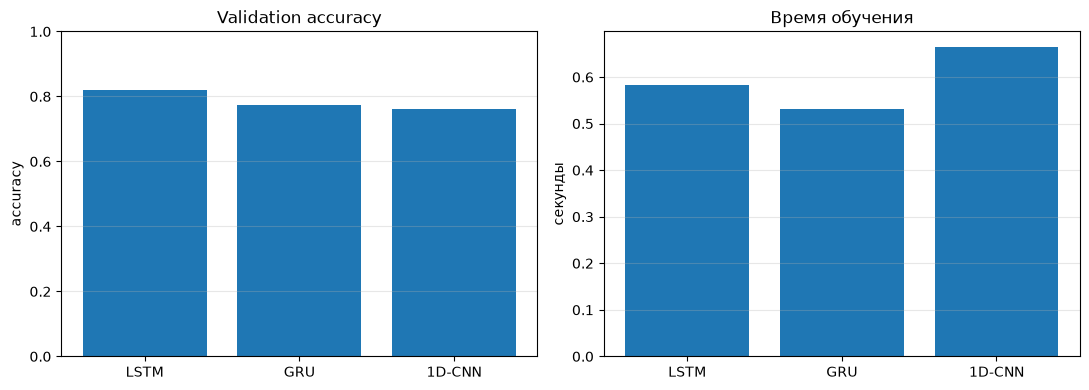

In [8]:
@torch.inference_mode()
def evaluate_classifier(model, loader):
    model.eval()
    criterion = nn.BCEWithLogitsLoss(reduction="sum")
    total_loss, total_correct, total_items = 0.0, 0, 0
    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        logits = model(inputs)
        total_loss += criterion(logits, targets).item()
        total_correct += ((logits >= 0) == targets.bool()).sum().item()
        total_items += targets.numel()
    return total_loss / total_items, total_correct / total_items


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def train_classifier(model, train_loader, val_loader, epochs=8, learning_rate=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    started = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, seen = 0.0, 0
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(inputs), targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * targets.numel()
            seen += targets.numel()
        if epoch in {1, epochs}:
            print(f"  эпоха {epoch:02d}: train loss = {running_loss / seen:.4f}")
    elapsed = time.perf_counter() - started
    val_loss, val_accuracy = evaluate_classifier(model, val_loader)
    return {
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "parameters": count_trainable_parameters(model),
        "seconds": elapsed,
    }


candidate_models = {}
candidate_rows = []
for architecture, model_class in [("LSTM", LSTMClassifier), ("GRU", GRUClassifier)]:
    for hidden_size in (32, 64):
        seed_offset = hidden_size + (0 if architecture == "LSTM" else 100)
        torch.manual_seed(SEED + seed_offset)
        model = model_class(hidden_size=hidden_size).to(DEVICE)
        print(f"{architecture}, hidden_size={hidden_size}")
        text_train_loader.generator.manual_seed(SEED)
        result = train_classifier(model, text_train_loader, text_val_loader)
        candidate_models[(architecture, hidden_size)] = model
        candidate_rows.append({
            "модель": architecture,
            "hidden_size": hidden_size,
            **result,
        })

candidate_results = pd.DataFrame(candidate_rows)
selected_rows = []
for architecture in ("LSTM", "GRU"):
    architecture_rows = candidate_results[candidate_results["модель"] == architecture]
    best_index = architecture_rows.sort_values(
        ["val_accuracy", "val_loss"], ascending=[False, True]
    ).index[0]
    best_row = candidate_results.loc[best_index].to_dict()
    hidden_size = int(best_row["hidden_size"])
    model = candidate_models[(architecture, hidden_size)]
    test_loss, test_accuracy = evaluate_classifier(model, text_test_loader)
    best_row.update({"test_loss": test_loss, "test_accuracy": test_accuracy})
    selected_rows.append(best_row)

torch.manual_seed(SEED + 250)
cnn_classifier = CNN1DClassifier().to(DEVICE)
print("1D-CNN")
text_train_loader.generator.manual_seed(SEED)
cnn_result = train_classifier(cnn_classifier, text_train_loader, text_val_loader)
cnn_test_loss, cnn_test_accuracy = evaluate_classifier(cnn_classifier, text_test_loader)
selected_rows.append({
    "модель": "1D-CNN",
    "hidden_size": np.nan,
    **cnn_result,
    "test_loss": cnn_test_loss,
    "test_accuracy": cnn_test_accuracy,
})

metric_note = (
    "МЕТРИКА НА ФИКСИРОВАННОЙ ПОДВЫБОРКЕ ИЗ ОПУБЛИКОВАННОГО TRAIN"
    if USE_RU_REVIEWS
    else "ДЕМОНСТРАЦИОННАЯ МЕТРИКА НА СИНТЕТИЧЕСКИХ ТЕКСТАХ"
)
print("\n" + metric_note)
print("\nКандидаты LSTM/GRU (выбор только по validation):")
print(candidate_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
text_results = pd.DataFrame(selected_rows)
print("\nВыбранные LSTM/GRU и 1D-CNN:")
print(text_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
validation_winner = text_results.sort_values(
    ["val_accuracy", "val_loss"], ascending=[False, True]
).iloc[0]
print(
    "Выбор по validation:", validation_winner["модель"],
    f"(val_accuracy={validation_winner['val_accuracy']:.4f})",
)
print("Test приведён только для итоговой оценки и не меняет этот выбор.")
if not USE_RU_REVIEWS:
    print("Эти accuracy нельзя выдавать за качество на реальных отзывах.")
else:
    print("Локальный test получен из train и не является official test набора.")

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(text_results["модель"], text_results["val_accuracy"])
axes[0].set(title="Validation accuracy", ylabel="accuracy", ylim=(0, 1))
axes[1].bar(text_results["модель"], text_results["seconds"])
axes[1].set(title="Время обучения", ylabel="секунды")
for axis in axes:
    axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

`Conv1d(kernel_size=5)` ищет локальные признаки, похожие на
5-граммы, а `AdaptiveMaxPool1d(1)` выбирает максимальный отклик каждого фильтра
по всему тексту. CNN хорошо параллелится, но на малом наборе накладные расходы
могут сделать её не быстрее рекуррентных моделей, поэтому используется
измеренное время из таблицы. LSTM хранит отдельно скрытое состояние и состояние
ячейки; GRU объединяет память компактнее и обычно имеет меньше параметров. Выбор
фиксируется по validation accuracy/loss до просмотра test; возможное преимущество
другой модели на локальном test не используется для повторной настройки.
Синтетический режим проверяет реализацию, но не заменяет эксперимент на данных.

---
## Часть В. Прогнозирование Jena Climate

### Загрузка без Keras

Архив скачивается напрямую по опубликованному адресу и распаковывается стандартным
`zipfile`. Повторный запуск использует локальный CSV из каталога `data/jena_climate`.

In [9]:
JENA_URL = (
    "https://storage.googleapis.com/tensorflow/"
    "tf-keras-datasets/jena_climate_2009_2016.csv.zip"
)
JENA_DIR = DATA_DIR / "jena_climate"
JENA_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = JENA_DIR / "jena_climate_2009_2016.csv.zip"
CSV_PATH = JENA_DIR / "jena_climate_2009_2016.csv"

if not CSV_PATH.exists():
    if not ZIP_PATH.exists():
        print("Скачивание Jena Climate...")
        urllib.request.urlretrieve(JENA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as archive:
        csv_members = [name for name in archive.namelist() if name.endswith(".csv")]
        if len(csv_members) != 1:
            raise RuntimeError(f"В архиве ожидался один CSV, найдено: {csv_members}")
        with archive.open(csv_members[0]) as source, CSV_PATH.open("wb") as target:
            target.write(source.read())

jena_df = pd.read_csv(CSV_PATH)
feature_names = jena_df.columns[1:].tolist()  # Date Time не подаём в модель
if "T (degC)" not in feature_names:
    raise ValueError("В Jena Climate не найден целевой столбец T (degC)")
temperature_index = feature_names.index("T (degC)")
raw_data = jena_df[feature_names].to_numpy(dtype=np.float32)
print("Размер таблицы:", jena_df.shape)
print("Признаков:", raw_data.shape[1], "цель:", feature_names[temperature_index])

Размер таблицы: (420551, 15)
Признаков: 14 цель: T (degC)


### Хронологическое разбиение и train-only нормализация

Первые 50% наблюдений образуют train, следующие 25% — validation, последние
25% — test. Среднее и стандартное отклонение вычисляются **только на train**.
Цель тоже нормализована, поэтому основная метрика ниже — normalized MAE. Для
интерпретации дополнительно печатается MAE в градусах Цельсия.

In [10]:
n_rows = len(raw_data)
train_end = int(0.50 * n_rows)
val_end = int(0.75 * n_rows)

train_mean = raw_data[:train_end].mean(axis=0)
train_std = raw_data[:train_end].std(axis=0)
train_std = np.where(train_std < 1e-7, 1.0, train_std)
normalized_data = ((raw_data - train_mean) / train_std).astype(np.float32)

print("Границы по времени:", {"train": train_end, "val": val_end, "test": n_rows})
print(
    "Train mean/std нормализованной температуры:",
    f"{normalized_data[:train_end, temperature_index].mean():.4f}",
    f"{normalized_data[:train_end, temperature_index].std():.4f}",
)

Границы по времени: {'train': 210275, 'val': 315413, 'test': 420551}
Train mean/std нормализованной температуры: -0.0000 1.0000


### Скользящие окна `Dataset` / `DataLoader`

Исходные измерения сделаны каждые 10 минут. Берём 120 точек с шагом 6, то есть
одно измерение в час примерно за 5 суток. Последняя входная точка находится за
24 часа (144 исходных шага) до цели. Такое индексирование принципиально: цель не
может оказаться внутри входного окна.

Для ограничения времени цели рассматриваются раз в час, а затем равномерно
прореживаются до 30 000 train и 6 000 validation/test примеров. Порядок границ
остаётся хронологическим; перемешивается только train `DataLoader`.

In [11]:
SEQUENCE_LENGTH = 120
SAMPLING_RATE = 6
FORECAST_HORIZON = 24 * 6
TARGET_STRIDE = 6
FIRST_TARGET = FORECAST_HORIZON + (SEQUENCE_LENGTH - 1) * SAMPLING_RATE


def select_target_indices(start, end, max_samples):
    first = max(start, FIRST_TARGET)
    candidates = np.arange(first, end, TARGET_STRIDE, dtype=np.int64)
    if len(candidates) > max_samples:
        positions = np.linspace(0, len(candidates) - 1, max_samples, dtype=np.int64)
        candidates = candidates[positions]
    return candidates


class JenaWindowDataset(Dataset):
    def __init__(self, values, target_indices, target_column):
        self.values = values
        self.target_indices = target_indices
        self.target_column = target_column

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, item):
        target_index = int(self.target_indices[item])
        last_input = target_index - FORECAST_HORIZON
        first_input = last_input - (SEQUENCE_LENGTH - 1) * SAMPLING_RATE
        window = self.values[first_input:last_input + 1:SAMPLING_RATE]
        target = self.values[target_index, self.target_column]
        if window.shape[0] != SEQUENCE_LENGTH:
            raise RuntimeError(f"Некорректная длина окна: {window.shape}")
        return torch.from_numpy(window), torch.tensor(target, dtype=torch.float32)


train_targets = select_target_indices(FIRST_TARGET, train_end, 30_000)
val_targets = select_target_indices(train_end, val_end, 6_000)
test_targets = select_target_indices(val_end, n_rows, 6_000)

train_jena = JenaWindowDataset(normalized_data, train_targets, temperature_index)
val_jena = JenaWindowDataset(normalized_data, val_targets, temperature_index)
test_jena = JenaWindowDataset(normalized_data, test_targets, temperature_index)

BATCH_SIZE = 256
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": DEVICE.type == "cuda",
}
train_jena_loader = DataLoader(
    train_jena,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)
val_jena_loader = DataLoader(val_jena, shuffle=False, **loader_options)
test_jena_loader = DataLoader(test_jena, shuffle=False, **loader_options)

window_example, target_example = train_jena[0]
assert window_example.shape == (SEQUENCE_LENGTH, raw_data.shape[1])
assert train_targets.max() < train_end <= val_targets.min()
assert val_targets.max() < val_end <= test_targets.min()
print("Число окон train/val/test:", len(train_jena), len(val_jena), len(test_jena))
print("Форма одного окна/цели:", tuple(window_example.shape), tuple(target_example.shape))

Число окон train/val/test: 30000 6000 6000
Форма одного окна/цели: (120, 14) ()


### Наивный бейзлайн

Для прогноза на 24 часа вперёд бейзлайн повторяет последнюю доступную температуру,
то есть температуру ровно за сутки до целевого момента. Это честный ориентир:
модель полезна только тогда, когда её MAE меньше.

In [12]:
@torch.inference_mode()
def evaluate_naive(loader):
    absolute_error, count = 0.0, 0
    for samples, targets in loader:
        predictions = samples[:, -1, temperature_index]
        absolute_error += torch.abs(predictions - targets).sum().item()
        count += targets.numel()
    return absolute_error / count


temperature_scale = float(train_std[temperature_index])
naive_val_mae = evaluate_naive(val_jena_loader)
naive_test_mae = evaluate_naive(test_jena_loader)
print(f"Naive val  normalized MAE: {naive_val_mae:.4f} ({naive_val_mae * temperature_scale:.3f} °C)")
print(f"Naive test normalized MAE: {naive_test_mae:.4f} ({naive_test_mae * temperature_scale:.3f} °C)")

Naive val  normalized MAE: 0.2773 (2.432 °C)
Naive test normalized MAE: 0.2976 (2.610 °C)


### LSTM(16) и LSTM(32) с recurrent dropout

В Keras `recurrent_dropout` маскирует рекуррентные связи внутри шага
`h[t-1] -> h[t]`. У встроенного `torch.nn.LSTM` такого аргумента нет:
параметр `dropout` накладывает dropout на **выходы между рекуррентными слоями**,
кроме последнего, и не подходит как замена.

Поэтому обязательная в КИМ конфигурация `LSTM(32, recurrent_dropout=0.25)` ниже
реализована ручным циклом на `LSTMCell`. Одна inverted-dropout-маска создаётся для
каждой последовательности в batch, применяется только к `h[t-1]` и остаётся
неизменной на всех временных шагах; состояние ячейки `c[t-1]` не маскируется. В
режиме `eval` dropout отключён.

In [13]:
class TemperatureLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size=16, batch_first=True)
        self.output = nn.Linear(16, 1)

    def forward(self, inputs):
        _, (hidden, _) = self.lstm(inputs)
        return self.output(hidden[-1]).squeeze(1)


class RecurrentDropoutTemperatureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, recurrent_dropout=0.25):
        super().__init__()
        if not 0.0 <= recurrent_dropout < 1.0:
            raise ValueError("recurrent_dropout должен быть в диапазоне [0, 1)")
        self.hidden_size = hidden_size
        self.recurrent_dropout = recurrent_dropout
        self.cell = nn.LSTMCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, inputs):
        batch_size = inputs.shape[0]
        hidden = inputs.new_zeros(batch_size, self.hidden_size)
        cell = inputs.new_zeros(batch_size, self.hidden_size)

        recurrent_mask = None
        if self.training and self.recurrent_dropout > 0.0:
            keep_probability = 1.0 - self.recurrent_dropout
            recurrent_mask = hidden.new_empty(hidden.shape)
            recurrent_mask.bernoulli_(keep_probability).div_(keep_probability)

        for step_inputs in inputs.unbind(dim=1):
            recurrent_hidden = (
                hidden if recurrent_mask is None else hidden * recurrent_mask
            )
            hidden, cell = self.cell(step_inputs, (recurrent_hidden, cell))
        return self.output(hidden).squeeze(1)


@torch.inference_mode()
def evaluate_forecaster(model, loader):
    model.eval()
    absolute_error, count = 0.0, 0
    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        absolute_error += torch.abs(model(inputs) - targets).sum().item()
        count += targets.numel()
    return absolute_error / count


def train_forecaster(model, train_loader, val_loader, epochs=8, patience=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    best_mae = float("inf")
    best_state = None
    stale_epochs = 0
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        squared_error, count = 0.0, 0
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            squared_error += loss.item() * targets.numel()
            count += targets.numel()

        val_mae = evaluate_forecaster(model, val_loader)
        print(
            f"  эпоха {epoch:02d}: train MSE={squared_error / count:.4f}, "
            f"val normalized MAE={val_mae:.4f}"
        )
        if val_mae < best_mae - 1e-4:
            best_mae = val_mae
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print("  ранняя остановка")
                break

    model.load_state_dict(best_state)
    return time.perf_counter() - started


input_size = raw_data.shape[1]
torch.manual_seed(SEED + 400)
lstm_forecaster = TemperatureLSTM(input_size).to(DEVICE)
torch.manual_seed(SEED + 432)
lstm_dropout_forecaster = RecurrentDropoutTemperatureLSTM(input_size).to(DEVICE)

shape_batch, _ = next(iter(train_jena_loader))
lstm_forecaster.eval()
lstm_dropout_forecaster.eval()
with torch.no_grad():
    print("Вход временного ряда:", tuple(shape_batch.shape))
    print("Выход LSTM(16):", tuple(lstm_forecaster(shape_batch.to(DEVICE)).shape))
    print(
        "Выход LSTM(32, recurrent_dropout=0.25):",
        tuple(lstm_dropout_forecaster(shape_batch.to(DEVICE)).shape),
    )

Вход временного ряда: (256, 120, 14)
Выход LSTM(16): (256,)
Выход LSTM(32, recurrent_dropout=0.25): (256,)


### Реальное обучение и итоговые MAE

In [14]:
print("Обучение LSTM(16)")
torch.manual_seed(SEED + 500)
train_jena_loader.generator.manual_seed(SEED)
lstm_seconds = train_forecaster(lstm_forecaster, train_jena_loader, val_jena_loader)
print("Обучение LSTM(32, recurrent_dropout=0.25)")
torch.manual_seed(SEED + 532)
train_jena_loader.generator.manual_seed(SEED)
lstm_dropout_seconds = train_forecaster(
    lstm_dropout_forecaster, train_jena_loader, val_jena_loader
)

lstm_val_mae = evaluate_forecaster(lstm_forecaster, val_jena_loader)
lstm_test_mae = evaluate_forecaster(lstm_forecaster, test_jena_loader)
lstm_dropout_val_mae = evaluate_forecaster(lstm_dropout_forecaster, val_jena_loader)
lstm_dropout_test_mae = evaluate_forecaster(lstm_dropout_forecaster, test_jena_loader)

jena_results = pd.DataFrame([
    {
        "модель": "Naive last temperature",
        "val normalized MAE": naive_val_mae,
        "test normalized MAE": naive_test_mae,
        "test MAE, °C": naive_test_mae * temperature_scale,
        "parameters": 0,
        "train seconds": 0.0,
    },
    {
        "модель": "LSTM(16)",
        "val normalized MAE": lstm_val_mae,
        "test normalized MAE": lstm_test_mae,
        "test MAE, °C": lstm_test_mae * temperature_scale,
        "parameters": count_trainable_parameters(lstm_forecaster),
        "train seconds": lstm_seconds,
    },
    {
        "модель": "LSTM(32, recurrent_dropout=0.25)",
        "val normalized MAE": lstm_dropout_val_mae,
        "test normalized MAE": lstm_dropout_test_mae,
        "test MAE, °C": lstm_dropout_test_mae * temperature_scale,
        "parameters": count_trainable_parameters(lstm_dropout_forecaster),
        "train seconds": lstm_dropout_seconds,
    },
])
print(jena_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

for name, score in [
    ("LSTM(16)", lstm_test_mae),
    ("LSTM(32, recurrent_dropout=0.25)", lstm_dropout_test_mae),
]:
    comparison = "лучше" if score < naive_test_mae else "не лучше"
    print(f"{name}: {comparison} test-бейзлайна на {abs(naive_test_mae - score):.4f}")

Обучение LSTM(16)


  эпоха 01: train MSE=0.3408, val normalized MAE=0.2856


  эпоха 02: train MSE=0.1515, val normalized MAE=0.2726


  эпоха 03: train MSE=0.1426, val normalized MAE=0.2688


  эпоха 04: train MSE=0.1392, val normalized MAE=0.2681


...

  эпоха 05: train MSE=0.1373, val normalized MAE=0.2671


  эпоха 06: train MSE=0.1363, val normalized MAE=0.2682


  эпоха 07: train MSE=0.1348, val normalized MAE=0.2659


  эпоха 08: train MSE=0.1339, val normalized MAE=0.2654


                          модель  val normalized MAE  test normalized MAE  test MAE, °C  parameters  train seconds
          Naive last temperature              0.2773               0.2976        2.6099           0         0.0000
                        LSTM(16)              0.2649               0.2804        2.4592        2065         8.1850
LSTM(32, recurrent_dropout=0.25)              0.2654               0.2812        2.4658        6177        51.7683
LSTM(16): лучше test-бейзлайна на 0.0172
LSTM(32, recurrent_dropout=0.25): лучше test-бейзлайна на 0.0164


Все значения в итоговой таблице измеряются, а не подставляются.
Обычный ориентир исправного запуска для рекуррентной модели — normalized MAE
порядка 0.25–0.29, но точное число зависит от устройства, версии PyTorch,
подвыборки и ранней остановки. Если модель не превзошла наивный **validation**-
бейзлайн, `epochs` и лимит train-окон настраиваются только по validation. После
фиксации конфигурации test оценивается один раз и больше не влияет на настройки.

В этой задаче выход — одно непрерывное значение без активации. MSE используется
для обучения, MAE — для понятной оценки. В бинарной классификации выше выход тоже
один, но это логит класса, а функция потерь — бинарная кросс-энтропия.
Наивный бейзлайн проверяет, извлекает ли сеть из истории больше информации, чем
простое сезонное правило «температура как сутки назад».